In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

###########################################
# GPU setup
###########################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

BATCH = 512
WIDTH = 64*2

###########################################
# Model
###########################################

class CNN(nn.Module):

    def __init__(self, width=64, classes=10):
        super().__init__()

        self.c1 = nn.Conv2d(3,width,3,padding=1)
        self.c2 = nn.Conv2d(width,width,3,padding=1)
        self.c3 = nn.Conv2d(width,width,3,padding=1)

        self.pool = nn.MaxPool2d(2)

        self.f1 = nn.Linear(width*4*4,256)
        self.f2 = nn.Linear(256,classes)

    def forward(self,x):

        x=self.pool(F.relu(self.c1(x)))
        x=self.pool(F.relu(self.c2(x)))
        x=self.pool(F.relu(self.c3(x)))

        x=torch.flatten(x,1)

        x=F.relu(self.f1(x))
        x=self.f2(x)

        return x


###########################################
# Data
###########################################

transform = transforms.ToTensor()

c10_train = torchvision.datasets.CIFAR10(
    "./data",train=True,download=True,transform=transform)

c10_test = torchvision.datasets.CIFAR10(
    "./data",train=False,download=True,transform=transform)

c100_train = torchvision.datasets.CIFAR100(
    "./data",train=True,download=True,transform=transform)

c100_test = torchvision.datasets.CIFAR100(
    "./data",train=False,download=True,transform=transform)

loader10 = torch.utils.data.DataLoader(
        c10_train,
        batch_size=BATCH,
        shuffle=True,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4
    )
test10 = torch.utils.data.DataLoader(
        c10_test,
        batch_size=BATCH,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True
    )

loader100 = torch.utils.data.DataLoader(
        c100_train,
        batch_size=BATCH,
        shuffle=True,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4
    )

test100 = torch.utils.data.DataLoader(
        c100_test,
        batch_size=BATCH,
        num_workers=12,
        pin_memory=True,
        persistent_workers=True
    )

###########################################
# Train + evaluate
###########################################

def train_epoch(model,loader,opt):

    loss_fn=nn.CrossEntropyLoss()
    model.train()

    for x,y in loader:

        x=x.to(device)
        y=y.to(device)

        opt.zero_grad()

        out=model(x)
        loss=loss_fn(out,y)

        loss.backward()
        opt.step()


def evaluate(model,loader):

    model.eval()
    correct=0
    total=0

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)
            y=y.to(device)

            pred=model(x).argmax(1)

            correct+=(pred==y).sum().item()
            total+=y.size(0)

    return correct/total


###########################################
# Mask utilities
###########################################

def make_mask(model):

    return {n:torch.ones_like(p)
            for n,p in model.named_parameters()}


def apply_mask(model, mask):

    for name, param in model.named_parameters():

        if name in mask:

            # skip layers with mismatched shape
            if mask[name].shape != param.shape:
                continue

            param.data.mul_(mask[name])


def global_prune(model,mask,percent):

    weights=[]

    for n,p in model.named_parameters():

        if "weight" in n:

            alive=p.data[mask[n].bool()].abs()
            weights.append(alive)

    thresh=torch.quantile(torch.cat(weights),percent)

    for n,p in model.named_parameters():

        if "weight" in n:

            new_mask=(p.data.abs()>thresh).float()
            mask[n]=mask[n]*new_mask

In [2]:
import time

def run_tests():

    cifar_10_acc = []
    dense_acc = []
    transfer_acc = []
    random_acc = []

    dense_time = 0
    transfer_time = 0
    random_time = 0


    ###########################################
    # 1. Find ticket on CIFAR10
    ###########################################

    print("\nFinding CIFAR10 ticket")

    model=CNN(WIDTH,10).to(device)

    initial={k:v.clone() for k,v in model.state_dict().items()}
    mask=make_mask(model)

    for r in range(10):

        opt=torch.optim.Adam(model.parameters(),lr=1e-3)

        for e in range(2):
            train_epoch(model,loader10,opt)

        acc=evaluate(model,test10)
        cifar_10_acc.append(acc)

        print("round",r,"acc",acc)

        global_prune(model,mask,0.2)

        model.load_state_dict(initial)
        apply_mask(model,mask)


    ###########################################
    # 2. Transfer mask to CIFAR100
    ###########################################

    print("\nTransfer mask to CIFAR100")

    model_transfer=CNN(WIDTH,100).to(device)
    apply_mask(model_transfer,mask)

    start_time = time.time()

    opt=torch.optim.Adam(model_transfer.parameters(),lr=1e-3)

    for e in range(10):

        train_epoch(model_transfer,loader100,opt)

        acc=evaluate(model_transfer,test100)
        transfer_acc.append(acc)

        print("transfer epoch",e,"acc",acc)

    end_time = time.time()
    transfer_time = end_time - start_time
    print("Transfer training time:", transfer_time, "seconds")


    ###########################################
    # 3. Dense CIFAR100 baseline
    ###########################################

    print("\nDense CIFAR100 baseline")

    dense=CNN(WIDTH,100).to(device)

    start_time = time.time()


    opt=torch.optim.Adam(dense.parameters(),lr=1e-3)
    for e in range(10):

        train_epoch(dense,loader100,opt)

        acc=evaluate(dense,test100)
        dense_acc.append(acc)

        print("dense epoch",e,"acc",acc)

    end_time = time.time()
    dense_time = end_time - start_time
    print("Dense training time:", dense_time, "seconds")


    ###########################################
    # 4. Random mask baseline
    ###########################################

    print("\nRandom mask baseline")

    rand=CNN(WIDTH,100).to(device)

    rand_mask=make_mask(rand)

    for n,p in rand_mask.items():

        rand_mask[n]=(torch.rand_like(p)>0.8).float()

    apply_mask(rand,rand_mask)

    start_time = time.time()

    opt=torch.optim.Adam(rand.parameters(),lr=1e-3)

    for e in range(10):

        train_epoch(rand,loader100,opt)

        acc=evaluate(rand,test100)
        random_acc.append(acc)

        print("random mask epoch",e,"acc",acc)

    end_time = time.time()
    random_time = end_time - start_time
    print("Random mask training time:", random_time, "seconds")

    return cifar_10_acc, dense_acc , transfer_acc , random_acc, dense_time, transfer_time, random_time


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose your experiment loop fills these lists
cifar_acc_all = []
dense_acc_all = []
transfer_acc_all = []
random_acc_all = []

dense_time_all = []
transfer_time_all = []
random_time_all = []

# Example: 100 runs
for _ in range(20):
    cifar_10_acc, dense_acc, transfer_acc, random_acc, dense_time, transfer_time, random_time = run_tests()
    cifar_acc_all.append(cifar_10_acc)
    dense_acc_all.append(dense_acc)
    transfer_acc_all.append(transfer_acc)
    random_acc_all.append(random_acc)

    dense_time_all.append(dense_time)
    transfer_time_all.append(transfer_time)
    random_time_all.append(random_time)











# Convert to numpy arrays
cifar_acc_all = np.array(cifar_acc_all)
dense_acc_all = np.array(dense_acc_all)

dense_time_all = np.array(dense_time_all)
transfer_time_all = np.array(transfer_time_all)
random_time_all = np.array(random_time_all)




Finding CIFAR10 ticket
round 0 acc 0.5503
round 1 acc 0.564
round 2 acc 0.5922
round 3 acc 0.5962
round 4 acc 0.6118
round 5 acc 0.6255
round 6 acc 0.6409
round 7 acc 0.6325
round 8 acc 0.6344
round 9 acc 0.6396

Transfer mask to CIFAR100
transfer epoch 0 acc 0.1013
transfer epoch 1 acc 0.1663
transfer epoch 2 acc 0.2178
transfer epoch 3 acc 0.2477
transfer epoch 4 acc 0.267
transfer epoch 5 acc 0.2914
transfer epoch 6 acc 0.3164
transfer epoch 7 acc 0.3214
transfer epoch 8 acc 0.3407
transfer epoch 9 acc 0.3379
Transfer training time: 180.4715449810028 seconds

Dense CIFAR100 baseline
dense epoch 0 acc 0.1516
dense epoch 1 acc 0.2285
dense epoch 2 acc 0.2731
dense epoch 3 acc 0.3145
dense epoch 4 acc 0.325
dense epoch 5 acc 0.3436
dense epoch 6 acc 0.3583
dense epoch 7 acc 0.3762
dense epoch 8 acc 0.3809
dense epoch 9 acc 0.3931
Dense training time: 34.344669580459595 seconds

Random mask baseline
random mask epoch 0 acc 0.1023
random mask epoch 1 acc 0.1546
random mask epoch 2 acc 0

In [4]:
import pickle

with open('cifar_acc_all.pkl', 'wb') as f:
    pickle.dump(cifar_acc_all,f)

with open('dense_acc_all.pkl', 'wb') as f:
    pickle.dump(dense_acc_all,f)

with open('transfer_acc_all.pkl', 'wb') as f:
    pickle.dump(transfer_acc_all,f)

with open('random_acc_all.pkl', 'wb') as f:
    pickle.dump(random_acc_all,f)

with open('dense_time_all.pkl', 'wb') as f:
    pickle.dump(dense_time_all,f)

with open('transfer_time_all.pkl', 'wb') as f:
    pickle.dump(transfer_time_all,f)

with open('random_time_all.pkl', 'wb') as f:
    pickle.dump(random_time_all,f)


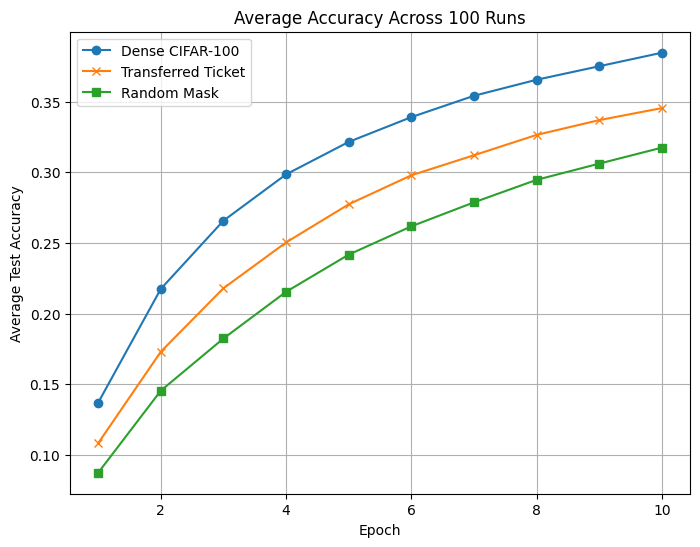

In [5]:



cifar_avg = np.mean(cifar_acc_all, axis=0)
dense_avg = np.mean(dense_acc_all, axis=0)
transfer_avg = np.mean(transfer_acc_all, axis=0)
random_avg = np.mean(random_acc_all, axis=0)

import matplotlib.pyplot as plt

epochs = range(1, len(dense_avg) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, dense_avg, label="Dense CIFAR-100", marker='o')
plt.plot(epochs, transfer_avg, label="Transferred Ticket",marker='x')
plt.plot(epochs, random_avg, label="Random Mask",marker='s')

plt.xlabel("Epoch")
plt.ylabel("Average Test Accuracy")
plt.title("Average Accuracy Across 100 Runs")
plt.legend()
plt.grid(True)

plt.show()




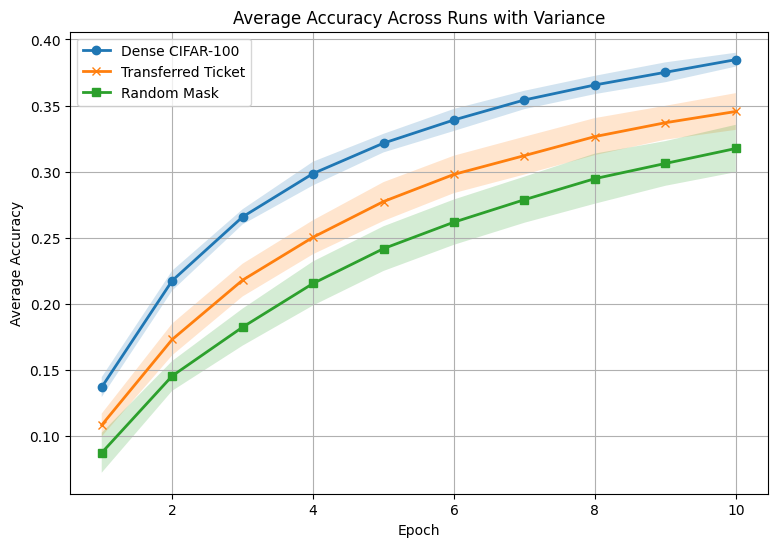

In [6]:
# Compute standard deviations across runs
cifar_std = np.std(cifar_acc_all, axis=0)
dense_std = np.std(dense_acc_all, axis=0)
transfer_std = np.std(transfer_acc_all, axis=0)
random_std = np.std(random_acc_all, axis=0)

epochs = range(1, len(dense_avg) + 1)

plt.figure(figsize=(9,6))

# Dense CIFAR-100
plt.plot(epochs, dense_avg, label="Dense CIFAR-100", linewidth=2,marker='o')
plt.fill_between(
    epochs,
    dense_avg - dense_std,
    dense_avg + dense_std,
    alpha=0.2
)

# Transfer ticket
plt.plot(epochs, transfer_avg, label="Transferred Ticket", linewidth=2,marker='x')
plt.fill_between(
    epochs,
    transfer_avg - transfer_std,
    transfer_avg + transfer_std,
    alpha=0.2
)

# Random mask
plt.plot(epochs, random_avg, label="Random Mask", linewidth=2,marker='s')
plt.fill_between(
    epochs,
    random_avg - random_std,
    random_avg + random_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy Across Runs with Variance")
plt.legend()
plt.grid(True)

plt.show()

C:\Users\Dzu\AppData\Local\Temp\ipykernel_11728\1164974369.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dense_time_all, transfer_time_all_graph, random_time_all], labels=["Dense CIFAR-100", "Transferred Ticket", "Random Mask"])


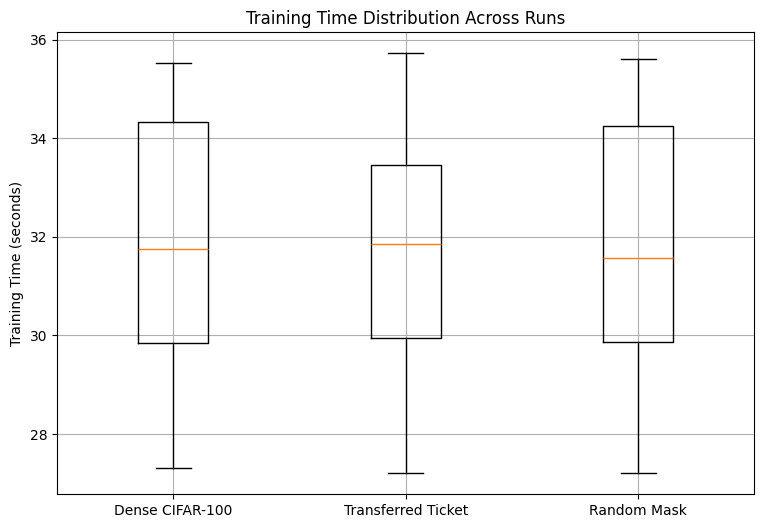

In [14]:
# plot times as box plots

transfer_time_all_graph = transfer_time_all[transfer_time_all < np.percentile(transfer_time_all, 95)]

plt.figure(figsize=(9,6))
plt.boxplot([dense_time_all, transfer_time_all_graph, random_time_all], labels=["Dense CIFAR-100", "Transferred Ticket", "Random Mask"])
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Distribution Across Runs")
plt.grid(True)
plt.show()


[35.17823052406311,
 35.72819471359253,
 32.27413582801819,
 33.423500776290894,
 33.495922803878784,
 35.72498679161072,
 28.54866623878479,
 32.529531717300415,
 27.21581768989563,
 32.56261444091797,
 34.56295084953308,
 31.26402449607849,
 29.988234996795654,
 29.105464935302734,
 29.92293953895569,
 29.816946029663086,
 31.587505340576172,
 31.755876302719116,
 31.857152700424194]